# Defensive effectiveness and group-stage progression

**Kushal Raut — Student number: 399210**

**Question:** Did teams that advanced from the FIFA World Cup 2026 group stage allow fewer shots on target per match than teams that were eliminated?

Run the cells from top to bottom, or choose **Restart Kernel and Run All Cells**. The notebook contains the complete workflow and saves results to `outputs/`. Launch it from this topic folder or the repository root. The statistical method is unchanged from the original script.

## 1. Imports and file paths

In [1]:
import json
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

%matplotlib inline

# Notebooks do not define __file__; locate the data from the kernel directory.
ROOT = Path.cwd()
if not (ROOT / "data" / "source_records.json").is_file():
    ROOT = ROOT / "01_defensive_effectiveness_Kushal_399210"
DATA = ROOT / "data"
OUTPUTS = ROOT / "outputs"
if not (DATA / "source_records.json").is_file():
    raise FileNotFoundError("Launch Jupyter from the repository root or the defensive topic folder.")

## 2. Source extraction and summary helpers

Rebuild the match dataset from saved FIFA evidence, retaining source URLs. Unknown total attempts remain missing; shots on target are required for this analysis.

In [2]:
# Full-time reports that could not be extracted are completed with the official
# FIFA match page / FIFA Training Centre post-match summary report.
# Keys are source-record indices; values are team A/B shots on target and source type.
FALLBACK = {
    3: (4, 2, "FIFA Training Centre post-match summary"),
    8: (7, 3, "FIFA Training Centre post-match summary"),
    10: (4, 7, "FIFA Training Centre post-match summary"),
    14: (0, 2, "FIFA official match page"),
    25: (4, 1, "FIFA Training Centre post-match summary"),
    28: (2, 3, "FIFA Training Centre post-match summary"),
    46: (2, 3, "FIFA official match page"),
}


def clean_team(name: str) -> str:
    """Normalize non-breaking spaces and surrounding whitespace in team names."""
    return name.replace("\xa0", " ").strip()


def build_dataset() -> None:
    """Rebuild one row per match from saved FIFA evidence, retaining source URLs."""
    records = json.loads((DATA / "source_records.json").read_text())
    rows = []

    for record in records:
        i = record["index"]
        excerpt = record["fulltime_excerpt"]
        # Capture total attempts and shots on target for both teams from the
        # team-statistics row, keeping one consistent definition across reports.
        match = re.search(
            r"(\d+)\s*/\s*(\d+) Attempts at Goal \(Total/On Target\) "
            r"(\d+)\s*/\s*(\d+)",
            excerpt,
        )
        if match:
            total_a, sot_a, total_b, sot_b = map(int, match.groups())
            evidence = "FIFA full-time match report, team statistics row"
            evidence_url = record["fulltime_url"]
        else:
            sot_a, sot_b, evidence = FALLBACK[i]
            # Fallback evidence supplies shots on target only; unknown totals
            # stay missing rather than being incorrectly recorded as zero.
            total_a = total_b = pd.NA
            evidence_url = (
                record["match_url"]
                if "match page" in evidence
                else record["summary_url"]
            )

        rows.append(
            {
                "match_id": record["match_id"],
                "date": record["date"],
                "group": record["group"],
                "team_a": clean_team(record["team_a"]),
                "team_b": clean_team(record["team_b"]),
                "score": record["score"],
                "team_a_total_attempts": total_a,
                "team_a_shots_on_target": sot_a,
                "team_b_total_attempts": total_b,
                "team_b_shots_on_target": sot_b,
                "evidence_type": evidence,
                "evidence_url": evidence_url,
                "fifa_match_url": record["match_url"],
                "fifa_fulltime_report_url": record["fulltime_url"],
                "fifa_summary_report_url": record["summary_url"],
            }
        )

    # Check the expected group-stage coverage before saving the rebuilt input.
    output = pd.DataFrame(rows)
    assert len(output) == 72
    assert output[["team_a_shots_on_target", "team_b_shots_on_target"]].notna().all().all()
    assert output["group"].value_counts().eq(6).all()
    teams = set(output["team_a"]) | set(output["team_b"])
    assert len(teams) == 48
    output.to_csv(DATA / "match_level_shots_on_target.csv", index=False)
    print(f"Saved {len(output)} matches covering {len(teams)} teams.")


def descriptive(values: pd.Series) -> dict[str, float]:
    """Summarize size, centre and spread; ddof=1 uses the sample SD (n - 1)."""
    return {
        "n": int(values.count()),
        "mean": float(values.mean()),
        "sd": float(values.std(ddof=1)),
        "median": float(values.median()),
        "minimum": float(values.min()),
        "q1": float(values.quantile(0.25)),
        "q3": float(values.quantile(0.75)),
        "maximum": float(values.max()),
    }

In [3]:
OUTPUTS.mkdir(parents=True, exist_ok=True)
build_dataset()
matches = pd.read_csv(DATA / "match_level_shots_on_target.csv")
qualification = json.loads((DATA / "qualified_teams.json").read_text())
# Flatten the Round of 32 pairings into a set for progression classification.
advanced = {team for pair in qualification["pairs"] for team in pair}
display(matches.head())

Saved 72 matches covering 48 teams.


,match_id,date,group,team_a,team_b,score,team_a_total_attempts,team_a_shots_on_target,team_b_total_attempts,team_b_shots_on_target,evidence_type,evidence_url,fifa_match_url,fifa_fulltime_report_url,fifa_summary_report_url
0,400021443,2026-06-11,A,Mexico,South Africa,2–0,16.0,4,3.0,2,"FIFA full-time match report, team statistics row",https://fdp.fifa.org/assetspublic/ce281/r12452...,https://www.fifa.com/en/match-centre/match/17/...,https://fdp.fifa.org/assetspublic/ce281/r12452...,https://www.fifatrainingcentre.com/media/nativ...
1,400021441,2026-06-11,A,South Korea,Czech Republic,2–1,15.0,6,6.0,4,"FIFA full-time match report, team statistics row",https://fdp.fifa.org/assetspublic/ce281/r12450...,https://www.fifa.com/en/match-centre/match/17/...,https://fdp.fifa.org/assetspublic/ce281/r12450...,https://www.fifatrainingcentre.com/media/nativ...
2,400021440,2026-06-18,A,Czech Republic,South Africa,1–1,14.0,3,17.0,4,"FIFA full-time match report, team statistics row",https://fdp.fifa.org/assetspublic/ce281/r12449...,https://www.fifa.com/en/match-centre/match/17/...,https://fdp.fifa.org/assetspublic/ce281/r12449...,https://www.fifatrainingcentre.com/media/nativ...
3,400021442,2026-06-18,A,Mexico,South Korea,1–0,NaN,4,NaN,2,FIFA Training Centre post-match summary,https://www.fifatrainingcentre.com/media/nativ...,https://www.fifa.com/en/match-centre/match/17/...,https://fdp.fifa.org/assetspublic/ce281/r12451...,https://www.fifatrainingcentre.com/media/nativ...
4,400021444,2026-06-24,A,Czech Republic,Mexico,0–3,13.0,1,11.0,5,"FIFA full-time match report, team statistics row",https://fdp.fifa.org/assetspublic/ce281/r12453...,https://www.fifa.com/en/match-centre/match/17/...,https://fdp.fifa.org/assetspublic/ce281/r12453...,https://www.fifatrainingcentre.com/media/nativ...


## 3. Data wrangling and validation

Each match becomes two team appearances. A team’s shots on target conceded equal its opponent’s shots on target.

In [4]:
# Data wrangling: turn each match into one record per team. The opponent's
# shots on target are the team's shots on target conceded.
a = matches[["match_id", "group", "team_a", "team_b", "team_b_shots_on_target"]].copy()
a.columns = ["match_id", "group", "team", "opponent", "shots_on_target_conceded"]
b = matches[["match_id", "group", "team_b", "team_a", "team_a_shots_on_target"]].copy()
b.columns = ["match_id", "group", "team", "opponent", "shots_on_target_conceded"]
appearances = pd.concat([a, b], ignore_index=True)
appearances["advanced"] = appearances["team"].isin(advanced)
appearances["progression"] = np.where(appearances["advanced"], "Advanced", "Eliminated")

# Each match contributes two appearances; each of the 48 teams plays three.
# Also ensure every qualifying team is present in the match dataset.
assert len(appearances) == 144
assert appearances.isna().sum().sum() == 0
assert appearances.groupby("team").size().eq(3).all()
assert appearances["team"].nunique() == 48
assert len(advanced) == 32 and advanced.issubset(set(appearances["team"]))
display(appearances.head())

,match_id,group,team,opponent,shots_on_target_conceded,advanced,progression
0,400021443,A,Mexico,South Africa,2,True,Advanced
1,400021441,A,South Korea,Czech Republic,4,False,Eliminated
2,400021440,A,Czech Republic,South Africa,4,False,Eliminated
3,400021442,A,Mexico,South Korea,2,True,Advanced
4,400021444,A,Czech Republic,Mexico,5,False,Eliminated


## 4. Unit of analysis and sampling limitation

Average the three group matches to obtain one observation per team. This analysis uses all 48 teams, a **census**, rather than a random sample. The assignment’s sampling requirement remains to be addressed. Teams share matches, so observations are not fully independent.

In [5]:
# Use one observation per team instead of treating repeated appearances as
# independent. This retains all 48 teams (a census); no sampling occurs here.
# Opponents still share matches, so independence remains approximate.
teams = (
    appearances.groupby(["group", "team", "advanced", "progression"], as_index=False)
    .agg(
        matches_played=("match_id", "nunique"),
        total_shots_on_target_conceded=("shots_on_target_conceded", "sum"),
        average_shots_on_target_conceded=("shots_on_target_conceded", "mean"),
    )
    .sort_values(["advanced", "average_shots_on_target_conceded", "team"], ascending=[False, True, True])
)
assert len(teams) == 48 and teams["matches_played"].eq(3).all()

advanced_values = teams.loc[teams["advanced"], "average_shots_on_target_conceded"]
eliminated_values = teams.loc[~teams["advanced"], "average_shots_on_target_conceded"]
display(teams.head())

,group,team,advanced,progression,matches_played,total_shots_on_target_conceded,average_shots_on_target_conceded
37,J,Argentina,True,Advanced,3,2,0.666667
30,H,Spain,True,Advanced,3,3,1.000000
1,A,Mexico,True,Advanced,3,5,1.666667
40,K,Colombia,True,Advanced,3,6,2.000000
32,I,France,True,Advanced,3,6,2.000000


## 5. Descriptive statistics

Compare group sizes, means, sample standard deviations, medians, quartiles and ranges.

In [6]:
desc = pd.DataFrame(
    [
        {"progression": "Advanced", **descriptive(advanced_values)},
        {"progression": "Eliminated", **descriptive(eliminated_values)},
    ]
)
display(desc)

,progression,n,mean,sd,median,minimum,q1,q3,maximum
0,Advanced,32,3.395833,1.189673,3.666667,0.666667,2.333333,4.333333,5.333333
1,Eliminated,16,5.666667,1.792990,5.666667,2.666667,4.250000,7.000000,9.666667


## 6. Confidence interval and Welch two-sample t-test

**H0:** The population means are equal. **H1:** The population means differ. Use a two-sided test with alpha = 0.05 and a 95% confidence interval for advanced minus eliminated.

Welch’s test does not assume equal variances. A negative difference indicates fewer shots conceded by advancing teams. Because this is a census, inference requires a broader conceptual population of comparable tournament performances; it is not uncertainty about these recorded 48 teams.

In [7]:
# Welch's two-sided test compares means without assuming equal variances.
# Its 95% interval estimates advanced minus eliminated: negative values
# indicate fewer shots conceded by advancing teams. Census inference is
# model-based; it does not quantify uncertainty about the recorded 48 teams.
result = stats.ttest_ind(advanced_values, eliminated_values, equal_var=False)
ci = result.confidence_interval(confidence_level=0.95)
difference = float(advanced_values.mean() - eliminated_values.mean())
# Cohen's d expresses the difference in pooled sample-SD units. This
# descriptive effect size does not change the Welch test or its interval.
effect_size = difference / np.sqrt(
    ((len(advanced_values) - 1) * advanced_values.var(ddof=1)
     + (len(eliminated_values) - 1) * eliminated_values.var(ddof=1))
    / (len(advanced_values) + len(eliminated_values) - 2)
)

inference = {
    "question": "Did advancing teams allow fewer shots on target per group-stage match than eliminated teams?",
    "unit_of_analysis": "Team (mean across all three group-stage matches)",
    "advanced_n": int(len(advanced_values)),
    "eliminated_n": int(len(eliminated_values)),
    "mean_difference_advanced_minus_eliminated": difference,
    "confidence_level": 0.95,
    "ci_low": float(ci.low),
    "ci_high": float(ci.high),
    "test": "Two-sided Welch independent-samples t-test",
    "null_hypothesis": "The population mean shots on target conceded per match is equal for advancing and eliminated teams.",
    "alternative_hypothesis": "The population means differ.",
    "t_statistic": float(result.statistic),
    "degrees_of_freedom": float(result.df),
    "p_value": float(result.pvalue),
    "alpha": 0.05,
    "cohens_d": float(effect_size),
    "decision": "Reject H0" if result.pvalue < 0.05 else "Fail to reject H0",
}
print(json.dumps(inference, indent=2))

{
  "question": "Did advancing teams allow fewer shots on target per group-stage match than eliminated teams?",
  "unit_of_analysis": "Team (mean across all three group-stage matches)",
  "advanced_n": 32,
  "eliminated_n": 16,
  "mean_difference_advanced_minus_eliminated": -2.270833333333333,
  "confidence_level": 0.95,
  "ci_low": -3.2981663598309767,
  "ci_high": -1.2435003068356894,
  "test": "Two-sided Welch independent-samples t-test",
  "null_hypothesis": "The population mean shots on target conceded per match is equal for advancing and eliminated teams.",
  "alternative_hypothesis": "The population means differ.",
  "t_statistic": -4.586327869784053,
  "degrees_of_freedom": 21.8190090680333,
  "p_value": 0.0001467680434174405,
  "alpha": 0.05,
  "cohens_d": -1.6048738869558332,
  "decision": "Reject H0"
}


## 7. Save prepared data and results

In [8]:
# Export intermediate datasets as well as summaries so results are auditable.
appearances.to_csv(OUTPUTS / "team_match_records.csv", index=False)
teams.to_csv(OUTPUTS / "team_level_analysis.csv", index=False)
desc.to_csv(OUTPUTS / "descriptive_statistics.csv", index=False)
(OUTPUTS / "inferential_results.json").write_text(json.dumps(inference, indent=2))

824

## 8. Visual comparison

The boxplots show group distributions, diamonds show means, and dots show individual teams. The random seed controls only plot jitter.

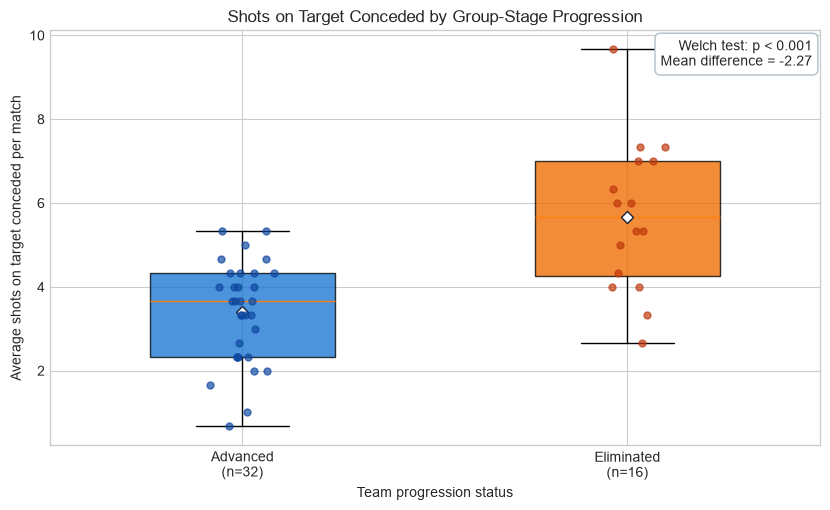

In [9]:
# Show group distributions, mean diamonds and individual team observations.
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(8.4, 5.2))
groups = [advanced_values, eliminated_values]
labels = ["Advanced\n(n=32)", "Eliminated\n(n=16)"]
box = ax.boxplot(groups, tick_labels=labels, patch_artist=True, widths=0.48, showmeans=True,
                 meanprops={"marker": "D", "markerfacecolor": "white", "markeredgecolor": "#152238"})
for patch, color in zip(box["boxes"], ["#1976D2", "#EF6C00"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.78)
# Seed only the horizontal jitter to keep overlapping points readable and
# the chart reproducible; this is not statistical sampling of the teams.
rng = np.random.default_rng(2026)
for x, values, color in zip([1, 2], groups, ["#0D47A1", "#BF360C"]):
    ax.scatter(rng.normal(x, 0.045, len(values)), values, s=25, alpha=0.68, color=color, zorder=3)
ax.set_title("Shots on Target Conceded by Group-Stage Progression")
ax.set_ylabel("Average shots on target conceded per match")
ax.set_xlabel("Team progression status")
p_label = "p < 0.001" if result.pvalue < 0.001 else f"p = {result.pvalue:.3f}"
ax.text(0.99, 0.98, f"Welch test: {p_label}\nMean difference = {difference:.2f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=10,
        bbox={"boxstyle": "round,pad=0.4", "facecolor": "white", "edgecolor": "#B0BEC5"})
fig.tight_layout()
fig.savefig(OUTPUTS / "defensive_effectiveness_boxplot.png", dpi=220)
plt.show()
plt.close(fig)

## 9. Interpretation and limitations

The original analysis estimated a mean difference of approximately -2.27 shots on target conceded per match, with a 95% interval of [-3.30, -1.24] and p approximately 0.000147. Check the executed results above when changing the data or code.

The result shows association, not causation. Opponent strength, possession and match circumstances may influence progression. Shots on target do not capture chance quality. The census and shared-match dependence limit inference; review these assumptions and the sampling requirement before submission.

## AI acknowledgement

Generative AI assisted with the original code and documentation, repository organization and notebook conversion. Review and understand each cell and record the assistance accurately in the signed AI Usage Declaration Form. Source claims were retained rather than independently reverified during conversion.